# Compare All Approaches

Compare different reward functions to see which works best!

In [1]:
from train import train
from utils import compare_results, save_results

print("Let's compare all reward functions!\n")

Let's compare all reward functions!



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Train with All Reward Functions

We'll test:
1. EMA Sharpe
2. Differential Sharpe
3. Multi-Objective
4. Simple Return


In [2]:
# Train technical agent with all reward functions
reward_types = [
    'ema_sharpe',
    'differential_sharpe', 
    'multi_objective',
    'simple_return',
]

results = []

for reward in reward_types:
    print(f"\n{'='*60}")
    print(f"Training with {reward}")
    print(f"{'='*60}")
    
    result = train(
        agent_type='technical',
        algorithm='PPO',
        reward_type=reward,
        verbose=False  # Set to True to see details
    )
    
    results.append(result)
    print(f"✓ {reward}: Test Sharpe = {result['test_sharpe']:.3f}")


Training with ema_sharpe
✓ ema_sharpe: Test Sharpe = 1.045

Training with differential_sharpe
✓ differential_sharpe: Test Sharpe = 0.989

Training with multi_objective
✓ multi_objective: Test Sharpe = 1.331

Training with simple_return
✓ simple_return: Test Sharpe = 1.031


## Compare Results

In [3]:
# Show comparison table
df = compare_results(results)

# Find the winner based on TEST performance
best = df.loc[df['test_sharpe'].idxmax()]
print(f"\n🏆 WINNER: {best['reward_type']}")
print(f"   Test Sharpe: {best['test_sharpe']:.3f}")


COMPARISON TABLE
agent_type algorithm         reward_type  train_sharpe  val_sharpe  test_sharpe  gamma  softmax_temperature  transaction_cost
 technical       PPO     multi_objective         2.818       2.261        1.331    0.9                  1.0            0.0025
 technical       PPO          ema_sharpe         1.321       2.303        1.045    0.9                  1.0            0.0025
 technical       PPO       simple_return         1.009       2.248        1.031    0.9                  1.0            0.0025
 technical       PPO differential_sharpe         1.385       2.343        0.989    0.9                  1.0            0.0025


🏆 WINNER: multi_objective
   Test Sharpe: 1.331


## Visualize Results

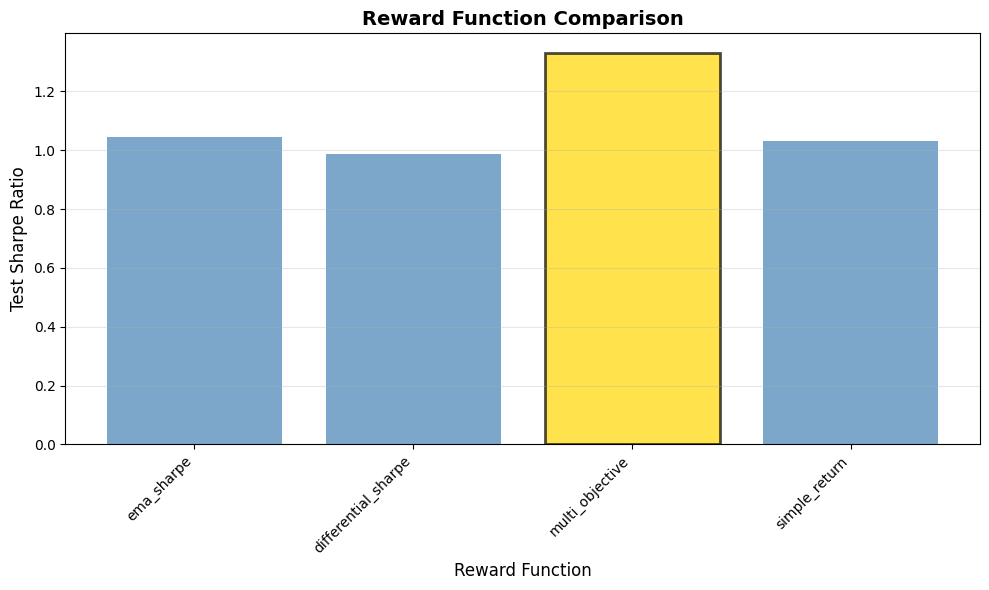


📊 Chart shows which reward function works best!


In [4]:
import matplotlib.pyplot as plt

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

reward_names = [r['reward_type'] for r in results]
test_sharpes = [r['test_sharpe'] for r in results]

bars = ax.bar(reward_names, test_sharpes, color='steelblue', alpha=0.7)

# Highlight the best
max_idx = test_sharpes.index(max(test_sharpes))
bars[max_idx].set_color('gold')
bars[max_idx].set_edgecolor('black')
bars[max_idx].set_linewidth(2)

ax.set_ylabel('Test Sharpe Ratio', fontsize=12)
ax.set_xlabel('Reward Function', fontsize=12)
ax.set_title('Reward Function Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Chart shows which reward function works best!")

## Save Results

In [5]:
# Save all results to JSON
save_results(
    {'comparison': results, 'best': best.to_dict()},
    'results/reward_comparison.json'
)

✓ Results saved to: results/reward_comparison.json


## 🎯 Next Steps

1. Try different algorithms (PPO, SAC, A2C)
2. Test on sentiment agent
3. Tune hyperparameters in `config.py`
4. Train longer by changing `TOTAL_STEPS`